# **🤖 Quora Question Pair Similarity Detection**

### *Semantic Similarity using BERT & Siamese Networks*

**Project Overview**
This project tackles the **Paraphrase Detection** task using the Quora Question Pairs dataset. The goal is to determine if two questions have the same intent/meaning. This is a critical problem in NLP with applications in:

* **Forum Moderation:** Reducing duplicate content.
* **Customer Support:** Automatically routing similar queries to existing FAQs.
* **Search Engine Optimization:** Canonicalizing content.

**Technical Approach**
We explore two distinct state-of-the-art approaches using **Transfer Learning**:

1. **Cross-Encoder (Binary Classification):** Fine-tuning a BERT-based model (`all-MiniLM-L6-v2`) with a classification head to predict a binary label (0 or 1).
2. **Bi-Encoder (Sentence Transformers):** Training a Siamese Network with **Contrastive Loss** to generate semantically meaningful sentence embeddings, where similar questions are close in vector space.

---


## 1. Environment Setup

We rely on the Hugging Face ecosystem (`transformers`, `datasets`, `sentence-transformers`) for model architectures and `torchmetrics` for tracking classification performance.

---


In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 43.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd#from transformers import
from sentence_transformers import SentenceTransformer, util
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import  AutoTokenizer,AutoModelForSequenceClassification
import torch
from tqdm.auto import tqdm
from torchmetrics import Accuracy
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

## 2. Data Ingestion & Preprocessing

The dataset consists of question pairs labelled as `is_duplicate` (1) or not (0).

* **Data Cleaning:** We remove rows with missing values to ensure stability.
* **Time Based Split :** We split the data into training (80%) and testing (20%) sets. Crucially, we use a **Time Based split** to preventing data leakage or bias.

In [ ]:
df=pd.read_csv("train.csv")

In [ ]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,38442,38443,Has anyone tried to harness the energy from li...,Can we store the energy from lightining?,1
1,1,130040,130041,Is there any statistics that can prove that ho...,Why are summer holidays important to you?,0
2,2,497108,497109,Which is the fastest supercomputer in the world?,Which is the fastest supercomputer in India?,0
3,3,42322,42323,How do I make $500k as a CPA?,How much money can I make with a CPA?,0
4,4,26031,29112,Why doesn't Apple launch a dual SIM iPhone?,Would you like a dual sim Iphone? Why doesn't ...,1


In [ ]:
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,1
question2,1
is_duplicate,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df=df.dropna()

In [ ]:
df1=df.drop(["id","qid1","qid2"],axis=1)

In [ ]:
train_df, test_df = train_test_split(
    df[["question1", "question2", "is_duplicate"]],
    test_size=0.2,
    stratify=df["is_duplicate"],
    random_state=42
)


In [ ]:
train_hf = Dataset.from_pandas(train_df)
test_hf  = Dataset.from_pandas(test_df)



## 3. Tokenization & Data Pipeline

Deep Learning models cannot process raw text. We must convert text into numerical tokens.

* **Tokenizer:** We use `bert-base-cased`.
* **Padding & Truncation:** We standardize sequence lengths to `128` tokens. This ensures efficient batch processing on the GPU.
* **PyTorch DataLoaders:** We convert the processed text into PyTorch tensors and wrap them in DataLoaders to handle batching and shuffling during training.

In [ ]:


tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

def tokenize_function(examples):
    return tokenizer(
        examples["question1"],
        examples["question2"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_tokenized = train_hf.map(
    tokenize_function,
    batched=True,
    remove_columns=["question1", "question2"]
)

test_tokenized = test_hf.map(
    tokenize_function,
    batched=True,
    remove_columns=["question1", "question2"]
)


Map:   0%|          | 0/194057 [00:00<?, ? examples/s]

Map:   0%|          | 0/48515 [00:00<?, ? examples/s]

In [ ]:
train_tokenized = train_tokenized.rename_column(
    "is_duplicate", "labels"
)

test_tokenized = test_tokenized.rename_column(
    "is_duplicate", "labels"
)

In [ ]:
if "__index_level_0__" in train_tokenized.column_names:
    train_tokenized = train_tokenized.remove_columns(["__index_level_0__"])
if "__index_level_0__" in test_tokenized.column_names:
    test_tokenized = test_tokenized.remove_columns(["__index_level_0__"])

In [ ]:
train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

In [ ]:
# Create a training data loader
train_dataloader = DataLoader(train_tokenized, shuffle=True, batch_size=16)

# Create an evaluation data loader
eval_dataloader = DataLoader(test_tokenized, batch_size=16)

In [ ]:
train_dataloader

## 4. Approach 1: Cross-Encoder Classification

In this approach, we feed *both* questions simultaneously into the model, separated by a special `[SEP]` token. The model's self-attention mechanism attends to both questions at once, allowing it to capture deep interaction features.

* **Architecture:** `all-MiniLM-L6-v2` (a distilled, efficient version of BERT) with a linear classification layer on top.
* **Pros:** Highly accurate because the model sees the interaction between words in both sentences.
* **Cons:** Computationally expensive for search (O(n^2) complexity), as every pair must be processed.

In [ ]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L6-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1e-1

In [ ]:

def get_bert_report(model, dataloader, device):
    # 1. Prepare
    model.eval()  # Set to evaluation mode
    all_preds = []
    all_labels = []

    print("⏳ Evaluating BERT model...")

    # 2. Loop through data (No Gradients needed)
    with torch.no_grad():
        for batch in tqdm(dataloader):
            # Move batch to GPU
            batch = {k: v.to(device) for k, v in batch.items()}

            # Forward pass
            outputs = model(**batch)

            # 3. Get Predictions
            # BERT outputs 'logits' (raw scores).
            # We take the standard argmax: Class 0 (Not Duplicate) or Class 1 (Duplicate)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)

            # Store results
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    # 4. Generate Report
    print("\n📊 BERT Classification Report:")
    print(classification_report(all_labels, all_preds))

    return all_preds

predictions = get_bert_report(model, eval_dataloader, device)

⏳ Evaluating BERT model...


  0%|          | 0/3033 [00:00<?, ?it/s]


📊 BERT Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.78      0.70     30603
           1       0.37      0.22      0.28     17912

    accuracy                           0.57     48515
   macro avg       0.50      0.50      0.49     48515
weighted avg       0.53      0.57      0.54     48515



We implement a custom training loop using **PyTorch**:

* **Optimizer:** `AdamW` (Adam with Weight Decay) is used for stable convergence.
* **Loss Function:** The model outputs `logits`. We use standard **Cross-Entropy Loss** (calculated internally by the Hugging Face model) to penalize incorrect class predictions.
* **Gradient Descent:** We iterate through the data, calculate gradients, and update model weights.


In [ ]:
def train_model(model, train_dataloader, num_epochs):
    optimizer = AdamW(model.parameters(), lr=2e-5)
    tr_losses = []

    print("🚀 Starting Fast Training...")
    model.train()

    for epoch in range(num_epochs):
        loop = tqdm(train_dataloader, leave=True)
        total_loss = 0

        for batch in loop:
            batch = {k: v.to(device) for k, v in batch.items()}

            optimizer.zero_grad()

            outputs = model(**batch)   # labels included
            loss = outputs.loss        # <-- THIS is key

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            loop.set_description(f"Epoch {epoch+1}")
            loop.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(train_dataloader)
        tr_losses.append(avg_loss)

    print("✅ Training complete.")
    plt.plot(tr_losses)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()


🚀 Starting Fast Training...


  0%|          | 0/12129 [00:00<?, ?it/s]

  0%|          | 0/12129 [00:00<?, ?it/s]

✅ Training complete.


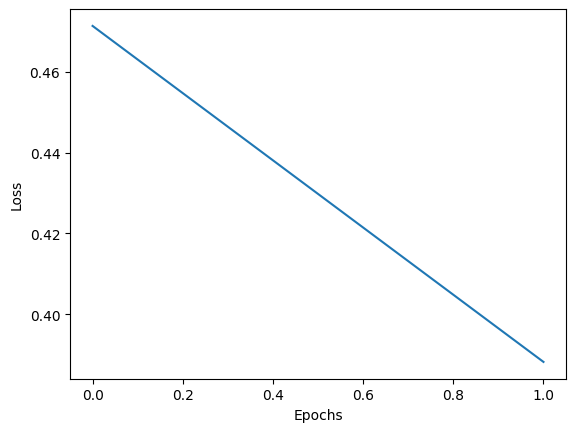

In [ ]:
train_model(model,train_dataloader,2)

In [ ]:
torch.save(model, 'my_model.pt')

### 4.2 Threshold Tuning

Standard classification uses a threshold of `0.5` (Argmax). However, for imbalanced datasets or specific business requirements (e.g., minimizing False Positives), tuning the decision threshold is vital.

* We analyze probabilities on the test set to find the **optimal threshold** that maximizes Accuracy or F1-Score.

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm

def tune_bert_threshold(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []

    print("⏳ Collecting probabilities from BERT...")

    with torch.no_grad():
        for batch in tqdm(dataloader):
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)
            logits = outputs.logits

            # 1. Convert Logits to Probabilities (0 to 1) using Softmax
            probs = F.softmax(logits, dim=-1)

            # We only care about the probability of being Class 1 (Duplicate)
            # This extracts the second column
            class_1_probs = probs[:, 1].cpu().numpy()

            all_probs.extend(class_1_probs)
            all_labels.extend(batch["labels"].cpu().numpy())

    # 2. Find the Best Threshold
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    best_acc = 0
    best_thresh = 0.5

    # Check thresholds from 0.1 to 0.9
    print("\n🔎 Searching for the best threshold...")
    for thresh in np.arange(0.1, 0.95, 0.05):
        preds = (all_probs > thresh).astype(int)
        acc = accuracy_score(all_labels, preds)

        # Print only if it improves
        if acc > best_acc:
            best_acc = acc
            best_thresh = thresh
            print(f"✨ New Best: Threshold {thresh:.2f} -> Accuracy {acc:.4f}")

    print(f"\n🏆 WINNER: Threshold {best_thresh:.2f}")

    # 3. Generate Final Report with the Winner
    final_preds = (all_probs > best_thresh).astype(int)
    print("\n" + classification_report(all_labels, final_preds))

# Run it
tune_bert_threshold(model, eval_dataloader, device)

⏳ Collecting probabilities from BERT...


  0%|          | 0/3033 [00:00<?, ?it/s]


🔎 Searching for the best threshold...
✨ New Best: Threshold 0.10 -> Accuracy 0.7393
✨ New Best: Threshold 0.15 -> Accuracy 0.7692
✨ New Best: Threshold 0.20 -> Accuracy 0.7898
✨ New Best: Threshold 0.25 -> Accuracy 0.8052
✨ New Best: Threshold 0.30 -> Accuracy 0.8146
✨ New Best: Threshold 0.35 -> Accuracy 0.8200
✨ New Best: Threshold 0.40 -> Accuracy 0.8219
✨ New Best: Threshold 0.45 -> Accuracy 0.8220

🏆 WINNER: Threshold 0.45

              precision    recall  f1-score   support

           0       0.84      0.88      0.86     30603
           1       0.78      0.72      0.75     17912

    accuracy                           0.82     48515
   macro avg       0.81      0.80      0.81     48515
weighted avg       0.82      0.82      0.82     48515



## 5. Approach 2: Bi-Encoder (Siamese Network)

While the Cross-Encoder is accurate, it is slow for retrieval tasks. Here, we train a **Sentence Transformer** (Bi-Encoder).

* **Architecture:** Two identical BERT networks (sharing weights) process each question *independently*.
* **Output:** Each question is converted into a fixed-size vector (embedding).
* **Pros:** Extremely fast for search. We can pre-compute embeddings and find duplicates using **Cosine Similarity** in milliseconds.

In [ ]:
# 1. Load a FRESH, Untrained model
print("⏳ Loading raw pre-trained model (No Fine-Tuning)...")
raw_model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Encode Test Data (Same test_df as before)
# We use the same data to make it a fair comparison
print("⏳ Computing embeddings...")
q1_raw = raw_model.encode(test_df['question1'].astype(str).tolist(),
                          batch_size=64, convert_to_tensor=True, show_progress_bar=True)
q2_raw = raw_model.encode(test_df['question2'].astype(str).tolist(),
                          batch_size=64, convert_to_tensor=True, show_progress_bar=True)

# 3. Compute Cosine Similarity
raw_scores = util.pairwise_cos_sim(q1_raw, q2_raw)

# 4. Check Performance
# We'll use a standard threshold of 0.75 for the raw model
# (Raw models often need a slightly lower threshold than fine-tuned ones)
raw_threshold = 0.75
raw_preds = (raw_scores > raw_threshold).float().cpu().numpy().astype(int)

# 5. Print Results
print("\n📉 Performance WITHOUT Fine-Tuning:")
print(f"Accuracy: {accuracy_score(test_labels, raw_preds):.4f}")
print("-" * 30)
print(classification_report(test_labels, raw_preds))

⏳ Loading raw pre-trained model (No Fine-Tuning)...
⏳ Computing embeddings...


Batches:   0%|          | 0/759 [00:00<?, ?it/s]

Batches:   0%|          | 0/759 [00:00<?, ?it/s]


📉 Performance WITHOUT Fine-Tuning:
Accuracy: 0.7718
------------------------------
              precision    recall  f1-score   support

           0       0.91      0.71      0.80     30603
           1       0.64      0.88      0.74     17912

    accuracy                           0.77     48515
   macro avg       0.77      0.79      0.77     48515
weighted avg       0.81      0.77      0.78     48515



In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### 5.1 Metric Learning with Contrastive Loss

Instead of simple classification, we use **Contrastive Loss**.

* **Concept:** The loss function pulls the embeddings of duplicate questions *closer together* (minimizing distance) and pushes non-duplicate questions *farther apart*.
* **Result:** The model learns a semantic vector space where distance equals meaning.

In [ ]:
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader


# 2. Prepare Data (The library needs a specific format)
# We convert your DataFrame rows into 'InputExample' objects
train_examples = []
for i, row in train_df.iterrows():
    train_examples.append(InputExample(
        texts=[str(row['question1']), str(row['question2'])],
        label=float(row['is_duplicate']) # Must be float for some loss functions
    ))

# 3. Create DataLoader (Batch size 32 or 64 works great on T4)
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=32)

# 4. Use Contrastive Loss (The Gold Standard for Duplicates)
# This loss pulls duplicate questions close and pushes non-duplicates apart.
train_loss = losses.ContrastiveLoss(model=model)

# 5. Train (1 Epoch is usually enough for MiniLM on this data)
print("🚀 Training started... this handles everything automatically.")
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=1,
    warmup_steps=100,
    show_progress_bar=True
)

# 6. Save it
model.save("my_duplicate_model")
print("✅ Done! Model saved.")

🚀 Training started... this handles everything automatically.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Step,Training Loss
500,0.015600
1000,0.014000
1500,0.013600
2000,0.013500
2500,0.012900
3000,0.012800
3500,0.012600
4000,0.012600
4500,0.012400
5000,0.012200


✅ Done! Model saved.


### 5.2 Evaluation: Cosine Similarity

To evaluate the Bi-Encoder, we don't use a classifier head. Instead, we compute the **Cosine Similarity** between the embeddings of Question 1 and Question 2.

* If Similarity > Threshold, they are duplicates.
* We again tune this threshold to maximize performance on the test set.

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Compute all Similarity Scores (if you haven't already)
# (Assuming 'cosine_scores' is still in memory from the previous step)
scores = cosine_scores.cpu().numpy() # Convert to numpy array
labels = test_labels

# 2. Loop to find the Best Threshold
best_acc = 0
best_threshold = 0.5

# Check thresholds from 0.50 to 0.95
for thresh in np.arange(0.5, 0.95, 0.05):
    preds = (scores > thresh).astype(int)
    acc = accuracy_score(labels, preds)

    print(f"Threshold {thresh:.2f} --> Accuracy: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = thresh

print(f"\n🚀 BEST RESULT: Threshold {best_threshold:.2f} gives Accuracy {best_acc:.4f}")

# 3. Generate Final Report with Best Threshold
final_preds = (scores > best_threshold).astype(int)
print(classification_report(labels, final_preds))

Threshold 0.50 --> Accuracy: 0.6985
Threshold 0.55 --> Accuracy: 0.7386
Threshold 0.60 --> Accuracy: 0.7757
Threshold 0.65 --> Accuracy: 0.8100
Threshold 0.70 --> Accuracy: 0.8379
Threshold 0.75 --> Accuracy: 0.8601
Threshold 0.80 --> Accuracy: 0.8708
Threshold 0.85 --> Accuracy: 0.8656
Threshold 0.90 --> Accuracy: 0.8357

🚀 BEST RESULT: Threshold 0.80 gives Accuracy 0.8708
              precision    recall  f1-score   support

           0       0.92      0.87      0.89     30603
           1       0.80      0.87      0.83     17912

    accuracy                           0.87     48515
   macro avg       0.86      0.87      0.86     48515
weighted avg       0.88      0.87      0.87     48515



## 6. Model Deployment (Interactive Demo)

A model is only useful if it can be consumed. We use **Gradio** to create a web-based interface for our model.

* **User Input:** Accepts two text strings.
* **Backend:** Runs the trained Sentence Transformer to generate embeddings and calculates similarity.
* **Output:** Returns a "Duplicate" or "Not Duplicate" label along with the confidence score.

This step demonstrates the ability to move a model from **Research** (Notebook) to **Production** (Application).

In [ ]:
import shutil

# Zip the folder 'my_duplicate_model' into a file named 'my_duplicate_model.zip'
shutil.make_archive('my_duplicate_model', 'zip', 'my_duplicate_model')

print("✅ Ready! Refresh the file browser on the left and look for 'my_duplicate_model.zip'")

✅ Ready! Refresh the file browser on the left and look for 'my_duplicate_model.zip'


In [ ]:
from sentence_transformers import SentenceTransformer

# Load directly from the folder
model = SentenceTransformer('my_duplicate_model')

In [ ]:
!pip install gradio

In [51]:
import gradio as gr
from sentence_transformers import util

# 1. Define the Logic (Returns 2 items: Label AND Score)
def predict_duplicate(question1, question2):
    # Wrap inputs in lists for the model
    emb1 = model.encode([question1], convert_to_tensor=True)
    emb2 = model.encode([question2], convert_to_tensor=True)

    # Calculate similarity
    score = util.pairwise_cos_sim(emb1, emb2).item()

    # Decision Logic (Using your 0.75 threshold)
    threshold = 0.75
    label = "✅ DUPLICATE" if score > threshold else "❌ NOT DUPLICATE"

    # Return TWO values
    return label, float(score)

# 2. Create the App Interface (Must match the 2 outputs above)
interface = gr.Interface(
    fn=predict_duplicate,
    inputs=[
        gr.Textbox(lines=2, placeholder="Type Question 1 here..."),
        gr.Textbox(lines=2, placeholder="Type Question 2 here...")
    ],
    outputs=[
        gr.Label(label="Prediction"),         # Output 1
        gr.Number(label="Similarity Score")   # Output 2
    ],
    title="🤖 Quora Duplicate Detector",
    description="Enter two questions to see if they are semantically the same.",
    examples=[
        ["How can I learn Python?", "What is the best way to start coding in Python?"],
        ["How do I cook pasta?", "Why is the sky blue?"]
    ]
)

# 3. Launch it once
interface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://cbead892b5b3b3b6da.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7866 <> https://cbead892b5b3b3b6da.gradio.live
